In [110]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

df =pd.read_csv('../data/routes/crm_scaled.csv')
# Select features for clustering
features = [
    'length_km',
    'collision_count',
    'casualty_count',
    'collision_count_per_km',
    'casualty_count_per_km',
    'poisson_risk_ratio_collision_count'
]
# Create feature DataFrame
X = df[features].copy()

# Handle any missing values
X = X.fillna(0)

# Apply scaling to normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features, index=df.index)

In [111]:
# K-Means Clustering
kmeans = KMeans(n_clusters=5, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

# DBSCAN (Density-Based Spatial Clustering)
dbscan = DBSCAN(eps=1.0, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

# Hierarchical Clustering
from sklearn.cluster import AgglomerativeClustering
hierarchical = AgglomerativeClustering(n_clusters=5)
df['hierarchical_cluster'] = hierarchical.fit_predict(X_scaled)

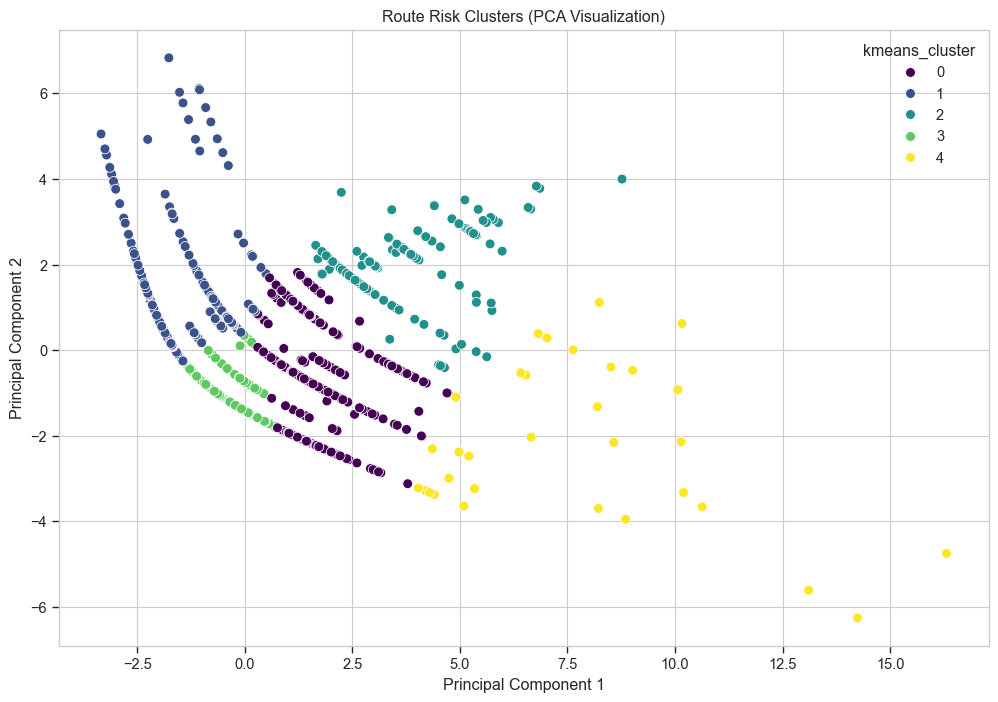

Cluster Statistics:
                 length_km  collision_count  casualty_count  \
kmeans_cluster                                               
4                1.559394         2.787879        3.575758   
2                5.580869         4.514286        4.857143   
0                3.449305         2.195991        2.351893   
3                2.972113         1.037685        1.099596   
1                6.842236         1.317419        1.374194   

                collision_count_per_km  casualty_count_per_km  \
kmeans_cluster                                                  
4                             1.876195               2.507134   
2                             0.830861               0.898688   
0                             0.711563               0.764338   
3                             0.365243               0.387098   
1                             0.206907               0.215818   

                poisson_risk_ratio_collision_count  
kmeans_cluster                     

In [112]:
# Apply PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['pca_1'] = X_pca[:, 0]
df['pca_2'] = X_pca[:, 1]

# Plot clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(x='pca_1', y='pca_2', hue='kmeans_cluster', data=df, palette='viridis', s=50)
plt.title('Route Risk Clusters (PCA Visualization)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.savefig('route_risk_clusters.png')
plt.show()

# Analyze cluster characteristics
# Sort clusters from highest to lowest average casualty rate
cluster_stats = df.groupby('kmeans_cluster')[features].mean().sort_values('casualty_count_per_km', ascending=False)
print("Cluster Statistics:\n", cluster_stats)

# Map clusters to readable risk categories
ranked_clusters = cluster_stats.index.tolist()

risk_mapping = {
    ranked_clusters[0]: "Very High Risk",
    ranked_clusters[1]: "High Risk",
    ranked_clusters[2]: "Moderate Risk",
    ranked_clusters[3]: "Low Risk",
    ranked_clusters[4]: "Minimal Risk"
}

df["risk_category"] = df["kmeans_cluster"].map(risk_mapping)


In [113]:
# Determine which cluster represents the highest risk
highest_risk_cluster = cluster_stats.index[0]

# Create risk categories based on clusters
risk_mapping = {
    highest_risk_cluster: 'Very High Risk',
    # Map other clusters based on their statistics
}

# Map clusters to risk categories
df['risk_category'] = df['kmeans_cluster'].map(risk_mapping)

# Get the top 20 highest risk routes for manual review
high_risk_routes = df[df['kmeans_cluster'] == highest_risk_cluster].sort_values(
    by=['casualty_count_per_km', 'collision_count_per_km'], 
    ascending=False
).head(20)

# print("\nTop 20 Highest Risk Routes for Manual Review:")
# print(high_risk_routes[['route_id', 'school_name', 'length_km', 
#                        'collision_count', 'casualty_count', 
#                        'collision_count_per_km', 'casualty_count_per_km']])

In [114]:
# Isolation Forest for anomaly detection
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination=0.05, random_state=42)
df['anomaly'] = iso_forest.fit_predict(X_scaled)
df['is_anomaly'] = df['anomaly'] == -1  # -1 indicates anomaly

# Get anomalous routes
anomalous_routes = df[df['is_anomaly']].sort_values(
    by=['casualty_count_per_km', 'collision_count_per_km'], 
    ascending=False
)

# print("\nAnomalous High-Risk Routes:")
# print(anomalous_routes[['route_id', 'school_name', 'length_km', 
#                        'collision_count', 'casualty_count', 
#                        'collision_count_per_km', 'casualty_count_per_km']])

In [116]:
# Combine clustering and anomaly detection for final classification
def assign_risk_level(row):
    if row['is_anomaly']:
        return 'Critical Risk'
    elif row['kmeans_cluster'] == highest_risk_cluster:
        return 'Very High Risk'
    # Add more conditions based on your clusters
    else:
        return 'Normal Risk'

df['final_risk_level'] = df.apply(assign_risk_level, axis=1)

# Final list of routes for manual review
final_review_routes = df[df['final_risk_level'].isin(['Critical Risk', 'Very High Risk'])].sort_values(
    by=['final_risk_level', 'casualty_count_per_km'], 
    ascending=[False, False]
)

# print("\nFinal Routes for Manual Review:")
# display(final_review_routes[['route_id', 'school_name', 'length_km', 
#                          'collision_count', 'casualty_count', 
#                          'final_risk_level']].head(30))

C:\Users\REALME\AppData\Local\Temp\ipykernel_11032\2243880339.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='final_risk_level', data=df, palette='rocket')


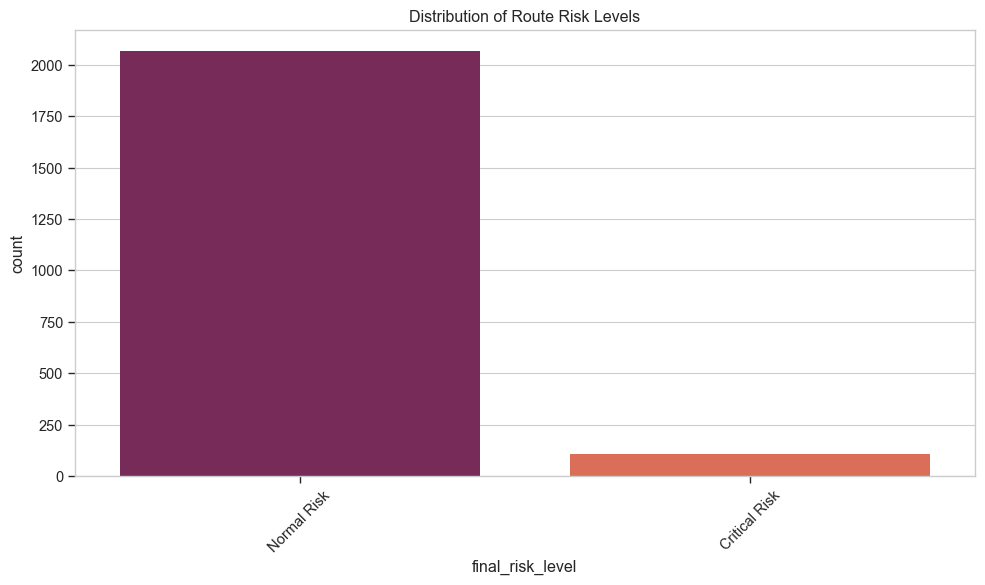

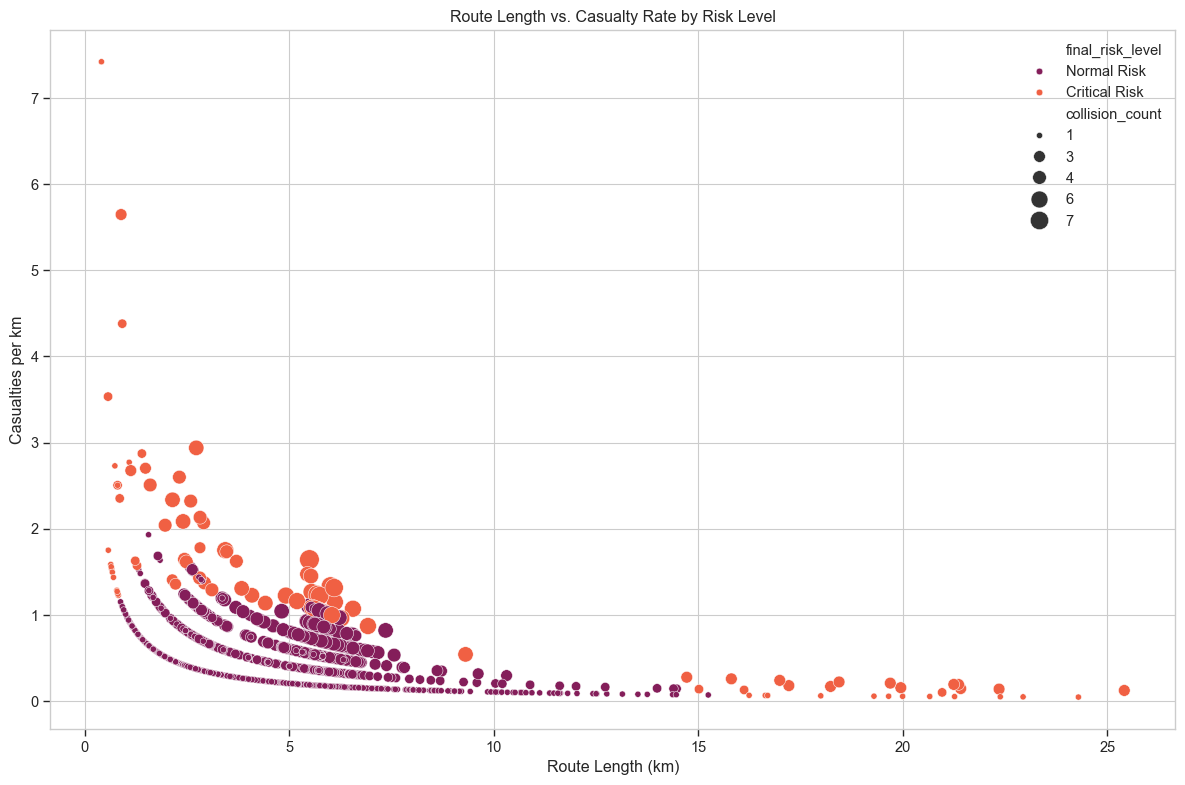

In [117]:
# Risk level distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='final_risk_level', data=df, palette='rocket')
plt.title('Distribution of Route Risk Levels')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('risk_level_distribution.png')

# Length vs Risk scatter plot
plt.figure(figsize=(12, 8))
sns.scatterplot(x='length_km', y='casualty_count_per_km', 
                hue='final_risk_level', size='collision_count',
                sizes=(20, 200), data=df, palette='rocket')
plt.title('Route Length vs. Casualty Rate by Risk Level')
plt.xlabel('Route Length (km)')
plt.ylabel('Casualties per km')
plt.tight_layout()
plt.savefig('length_vs_risk.png')

In [118]:
# Refine the risk classification to be more practical
def refined_risk_level(row):
    # Only consider routes as Critical Risk if they have sufficient collisions
    if row['final_risk_level'] == 'Critical Risk':
        if row['collision_count'] >= 3 and row['length_km'] >= 0.5:
            return 'Critical Risk'
        elif row['collision_count'] >= 2:
            return 'High Risk'
        else:
            return 'Moderate Risk'
    else:
        return row['final_risk_level']

df['refined_risk_level'] = df.apply(refined_risk_level, axis=1)
df
df.to_csv('../data/clustered.csv')

### 1

In [106]:
# Add practical refinements to risk classification
def practical_risk_assessment(df):
    # Create copy to avoid modifying original
    df_refined = df.copy()
    
    # Define practical risk criteria
    df_refined['practical_risk_level'] = 'Low Priority'
    
    # High priority routes: Substantial length with multiple collisions
    high_priority_mask = (
        (df_refined['collision_count'] >= 3) & 
        (df_refined['length_km'] >= 0.5) &
        (df_refined['refined_risk_level'].isin(['Critical Risk', 'High Risk']))
    )
    df_refined.loc[high_priority_mask, 'practical_risk_level'] = 'High Priority'
    
    # Medium priority routes: Either shorter with multiple collisions or longer with fewer collisions
    medium_priority_mask = (
        ((df_refined['collision_count'] >= 2) & (df_refined['length_km'] < 0.5) & 
         (df_refined['refined_risk_level'].isin(['Critical Risk', 'High Risk']))) |
        ((df_refined['collision_count'] >= 1) & (df_refined['length_km'] >= 1.0) & 
         (df_refined['refined_risk_level'].isin(['Critical Risk', 'High Risk', 'Moderate Risk'])))
    )
    df_refined.loc[medium_priority_mask, 'practical_risk_level'] = 'Medium Priority'
    
    # Calculate the practical priority counts
    priority_counts = df_refined['practical_risk_level'].value_counts()
    
    print(f"High Priority Routes: {priority_counts.get('High Priority', 0)}")
    print(f"Medium Priority Routes: {priority_counts.get('Medium Priority', 0)}")
    print(f"Low Priority Routes: {priority_counts.get('Low Priority', 0)}")
    
    return df_refined

def create_council_priority_table(df):
    """Generate a table of priority routes for city council"""
    
    # Filter to only high priority routes
    high_priority = df[df['practical_risk_level'] == 'High Priority'].sort_values(
        by=['casualty_count', 'collision_count'], ascending=False
    ).head(15)
    
    # Select and rename columns for presentation
    columns = {
        'school_name': 'School',
        'route_id': 'Route ID',
        'borough': 'Borough',
        'length_km': 'Length (km)',
        'collision_count': 'Collisions',
        'casualty_count': 'Casualties',
        'collision_count_per_km': 'Collisions/km',
        'casualty_count_per_km': 'Casualties/km'
    }
    
    display_table = high_priority[columns.keys()].rename(columns=columns).copy()
    
    # Format numeric columns
    for col in ['Length (km)', 'Collisions/km', 'Casualties/km']:
        display_table[col] = display_table[col].round(2)
    
    # Add a rank column
    display_table.insert(0, 'Priority Rank', range(1, len(display_table) + 1))
    
    return display_table

def borough_analysis(df):
    """Analyze risk patterns by borough for strategic planning"""
    
    # Calculate borough-level statistics
    borough_stats = df.groupby('borough').agg(
        total_routes=('route_id', 'nunique'),
        high_priority_routes=('practical_risk_level', lambda x: (x == 'High Priority').sum()),
        medium_priority_routes=('practical_risk_level', lambda x: (x == 'Medium Priority').sum()),
        total_collisions=('collision_count', 'sum'),
        total_casualties=('casualty_count', 'sum'),
        avg_collisions_per_route=('collision_count', 'mean'),
        avg_casualties_per_route=('casualty_count', 'mean')
    ).reset_index()
    
    # Calculate percentages
    borough_stats['high_priority_percent'] = (borough_stats['high_priority_routes'] / 
                                             borough_stats['total_routes'] * 100).round(1)
    borough_stats['medium_priority_percent'] = (borough_stats['medium_priority_routes'] / 
                                               borough_stats['total_routes'] * 100).round(1)
    
    # Sort by high priority percentage
    borough_stats = borough_stats.sort_values('high_priority_percent', ascending=False)
    
    return borough_stats

In [107]:
df = practical_risk_assessment(df)
create_council_priority_table(df)
borough_analysis(df)

High Priority Routes: 1
Medium Priority Routes: 90
Low Priority Routes: 2084


,borough,total_routes,high_priority_routes,medium_priority_routes,total_collisions,total_casualties,avg_collisions_per_route,avg_casualties_per_route,high_priority_percent,medium_priority_percent
3,Sheffield,302,1,36,438,478,1.450331,1.582781,0.3,11.9
0,Barnsley,486,0,7,756,774,1.555556,1.592593,0.0,1.4
1,Doncaster,775,0,39,1383,1543,1.784516,1.990968,0.0,5.0
2,Rotherham,612,0,8,1083,1111,1.769608,1.815359,0.0,1.3


In [108]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Set the style for professional visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

# Custom color palette that looks professional
sns.set_palette(sns.color_palette("hls", 5))

# 1. Improved PCA Visualization
def plot_pca_clusters(df, save_path='improved_pca_clusters.png'):
    plt.figure(figsize=(12, 9))
    
    # Add jitter to better visualize overlapping points
    x_jitter = np.random.normal(0, 0.05, size=len(df))
    y_jitter = np.random.normal(0, 0.05, size=len(df))
    
    # Create scatter plot with enhanced aesthetics
    scatter = sns.scatterplot(
        x=df['pca_1'] + x_jitter, 
        y=df['pca_2'] + y_jitter,
        hue='refined_risk_level',
        size='collision_count',
        sizes=(20, 200),
        alpha=0.7,
        data=df
    )
    
    # Improve legend
    plt.legend(title='Risk Level', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Add titles and labels
    plt.title('School Route Risk Clustering Analysis', fontsize=16, fontweight='bold')
    plt.xlabel('Principal Component 1 (Risk Intensity)', fontsize=12)
    plt.ylabel('Principal Component 2 (Route Characteristics)', fontsize=12)
    
    # Add annotations for key insights
    plt.annotate(
        'Critical Risk Routes',
        xy=(8, 0),
        xytext=(9, 2),
        fontsize=10,
        arrowprops=dict(arrowstyle='->', color='black')
    )
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    return save_path

# 2. Improved Risk Distribution with percentages
def plot_risk_distribution(df, save_path='improved_risk_distribution.png'):
    plt.figure(figsize=(12, 8))
    
    # Count routes by risk level
    risk_counts = df['refined_risk_level'].value_counts().sort_index()
    total_routes = len(df)
    
    # Create bar chart with percentages
    ax = sns.barplot(x=risk_counts.index, y=risk_counts.values, palette='viridis')
    
    # Add percentage labels
    for i, v in enumerate(risk_counts.values):
        percentage = (v / total_routes) * 100
        ax.text(i, v + 5, f"{percentage:.1f}%", ha='center', fontsize=10)
    
    # Add count labels
    for i, v in enumerate(risk_counts.values):
        ax.text(i, v/2, f"n={v}", ha='center', fontsize=10, color='white', fontweight='bold')
    
    # Enhance the chart
    plt.title('Distribution of School Route Risk Levels', fontsize=16, fontweight='bold')
    plt.xlabel('Risk Level', fontsize=14)
    plt.ylabel('Number of Routes', fontsize=14)
    plt.xticks(rotation=45)
    
    # Add total count as text
    plt.text(0.02, 0.95, f"Total Routes: {total_routes}", 
             transform=ax.transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.7))
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()
    
    return save_path

# 3. Enhanced Length vs. Casualty Rate Plot
def plot_length_vs_casualty(df, save_path='improved_length_vs_casualty.png'):
    plt.figure(figsize=(14, 10))
    
    # Create the scatter plot
    scatter = sns.scatterplot(
        x='length_km',
        y='casualty_count_per_km',
        hue='refined_risk_level',
        size='collision_count',
        sizes=(20, 200),
        alpha=0.7,
        palette='viridis',
        data=df
    )
    
    # Set log scale for y-axis to better visualize the distribution
    plt.yscale('symlog')
    
    # Customize the plot
    plt.title('Route Risk Analysis: Length vs. Casualty Rate', fontsize=16, fontweight='bold')
    plt.xlabel('Route Length (km)', fontsize=14)
    plt.ylabel('Casualties per km (log scale)', fontsize=14)
    plt.grid(True, alpha=0.3)
    
    # Move the legend outside the plot
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Highlight high priority routes (annotation for top 5 critical routes)
    high_priority = df[df['refined_risk_level'] == 'Critical Risk'].sort_values(
        by=['casualty_count', 'collision_count'], ascending=False).head(5)
    
    for idx, row in high_priority.iterrows():
        plt.annotate(
            f"{row['school_name'].split(' ')[0]}",
            xy=(row['length_km'], row['casualty_count_per_km']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.6)
        )
    
    # Add reference lines
    plt.axhline(y=df['casualty_count_per_km'].median(), color='gray', linestyle='--', 
                alpha=0.5, label=f"Median: {df['casualty_count_per_km'].median():.2f}")
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    return save_path

# 4. Priority Routes Table Figure (Top 15 Critical Routes)
def create_priority_routes_table(df, save_path='priority_routes_table.png'):
    # Filter to most important routes for city council
    priority_routes = df[
        (df['refined_risk_level'] == 'Critical Risk') & 
        (df['collision_count'] >= 3) &
        (df['length_km'] >= 0.5)
    ].sort_values(by=['casualty_count', 'collision_count_per_km'], ascending=False).head(15)
    
    # Select relevant columns for presentation
    display_cols = [
        'school_name', 'route_id', 'borough', 'length_km', 
        'collision_count', 'casualty_count', 
        'collision_count_per_km', 'casualty_count_per_km'
    ]
    
    priority_table = priority_routes[display_cols].copy()
    
    # Rename columns for better presentation
    priority_table.columns = [
        'School', 'Route ID', 'Borough', 'Length (km)', 
        'Collisions', 'Casualties', 
        'Collisions/km', 'Casualties/km'
    ]
    
    # Round numeric columns
    for col in ['Length (km)', 'Collisions/km', 'Casualties/km']:
        priority_table[col] = priority_table[col].round(2)
    
    # Create a figure with a table
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.axis('off')
    
    # Create table
    table = ax.table(
        cellText=priority_table.values,
        colLabels=priority_table.columns,
        loc='center',
        cellLoc='center',
        colColours=['#f2f2f2'] * len(priority_table.columns),
        cellColours=[['#ffffff' if i % 2 == 0 else '#f9f9f9' for j in range(len(priority_table.columns))] for i in range(len(priority_table))]
    )
    
    # Style the table
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale()  # Adjust row height
    
    # Add title
    plt.title('Priority Routes for Safety Intervention', fontsize=16, fontweight='bold', pad=20)
    plt.figtext(0.5, 0.01, 'These routes should be prioritized by the City Council for safety improvements', 
                ha='center', fontsize=12, style='italic')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    return save_path

# 5. Borough Risk Assessment (Horizontal Bar Chart)
def plot_borough_risk(df, save_path='borough_risk_assessment.png'):
    plt.figure(figsize=(14, 8))
    
    # Calculate high risk routes by borough
    borough_data = df.groupby('borough')['refined_risk_level'].apply(
        lambda x: (x == 'Critical Risk').sum() / len(x) * 100
    ).sort_values(ascending=True)
    
    # Create horizontal bar chart
    ax = sns.barplot(x=borough_data.values, y=borough_data.index, palette='viridis')
    
    # Add percentage labels
    for i, v in enumerate(borough_data.values):
        ax.text(v + 0.5, i, f"{v:.1f}%", va='center', fontsize=10)
    
    # Customize the plot
    plt.title('Percentage of Critical Risk Routes by Borough', fontsize=16, fontweight='bold')
    plt.xlabel('Percentage of Routes Classified as Critical Risk', fontsize=14)
    plt.ylabel('Borough', fontsize=14)
    
    # Add count information
    for i, borough in enumerate(borough_data.index):
        count = len(df[df['borough'] == borough])
        ax.text(0.5, i, f"n={count}", va='center', fontsize=10, color='white', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()
    
    return save_path

# Function to run all visualizations
def create_all_professional_visualizations(df):
    """Generate all professional visualizations for the report"""
    results = {
        'pca': plot_pca_clusters(df),
        'distribution': plot_risk_distribution(df),
        'length_vs_casualty': plot_length_vs_casualty(df),
        'priority_table': create_priority_routes_table(df),
        'borough_risk': plot_borough_risk(df)
    }
    
    return results

# a

C:\Users\REALME\AppData\Local\Temp\ipykernel_11032\997730761.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=risk_counts.index, y=risk_counts.values, palette='viridis')


TypeError: Table.scale() missing 2 required positional arguments: 'xscale' and 'yscale'

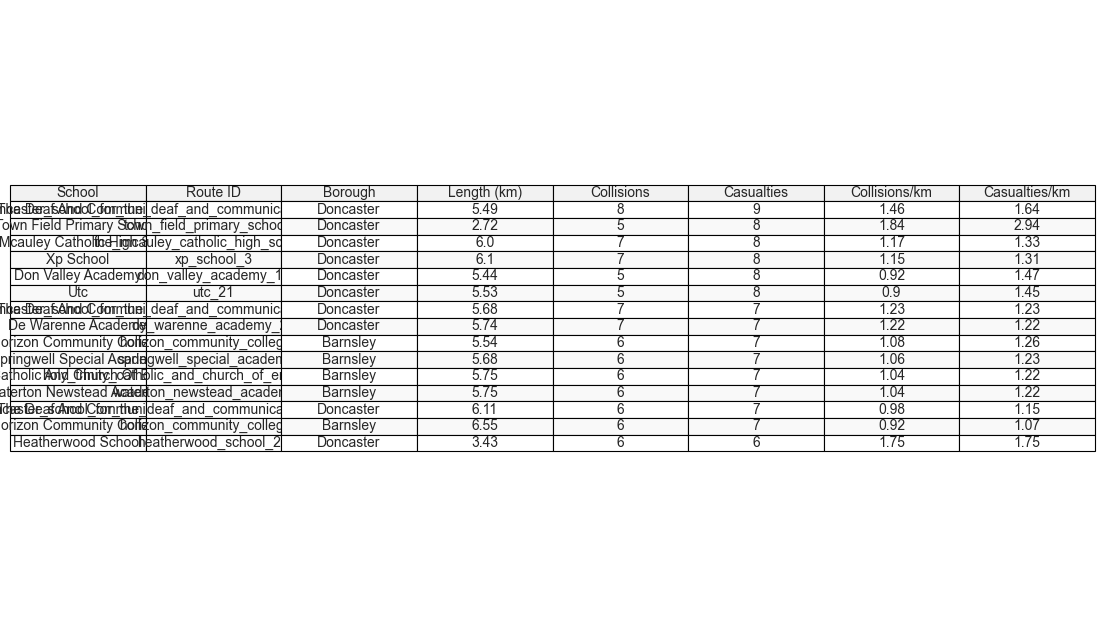

In [109]:
create_all_professional_visualizations(df)

In [ ]:
crm_scaled.to_csv('../data/routes/crm_scaled.csv')

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('../data/stats19_routes_combined.csv', low_memory=False)
df.columns


Index(['Unnamed: 0', 'accident_index', 'accident_year', 'accident_reference',
       'vehicle_reference', 'casualty_reference', 'casualty_class',
       'sex_of_casualty', 'age_of_casualty', 'age_band_of_casualty',
       'casualty_severity', 'pedestrian_location', 'pedestrian_movement',
       'car_passenger', 'bus_or_coach_passenger',
       'pedestrian_road_maintenance_worker', 'casualty_type',
       'casualty_home_area_type', 'casualty_imd_decile', 'lsoa_of_casualty',
       'enhanced_casualty_severity', 'casualty_distance_banding',
       'location_easting_osgr', 'location_northing_osgr', 'longitude',
       'latitude', 'police_force', 'accident_severity', 'number_of_vehicles',
       'number_of_casualties', 'date', 'day_of_week', 'time',
       'local_authority_district', 'local_authority_ons_district',
       'local_authority_highway', 'first_road_class', 'first_road_number',
       'road_type', 'speed_limit', 'junction_detail', 'junction_control',
       'second_road_class', '

In [2]:
cluster_df = pd.read_csv('../data/clustered.csv', low_memory=False)
# cluster_df.)
cluster_df
df_with_risk = df.merge(
    cluster_df[['route_id', 'refined_risk_level']],
    on='route_id',
    how='inner'  # or 'left' if you want to keep all STATS19 rows
)

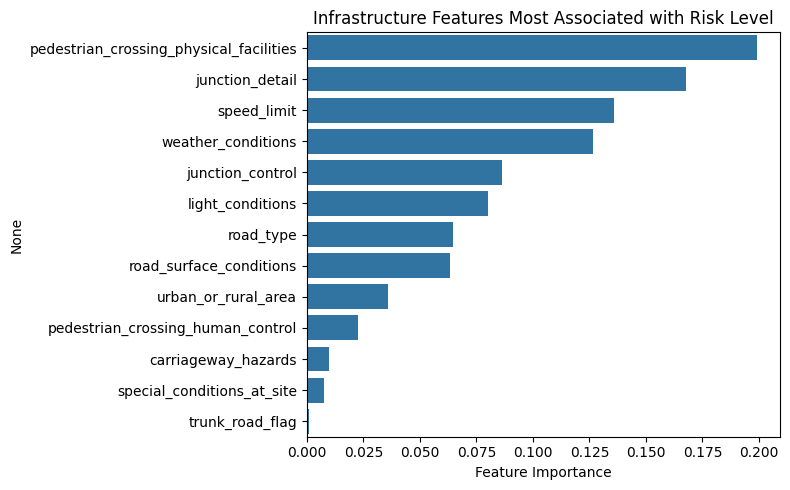

In [3]:
from sklearn.preprocessing import OneHotEncoder

# Only use infra columns
infra_cols = [
    'road_type', 'speed_limit', 'junction_detail', 'junction_control',
    'pedestrian_crossing_human_control', 'pedestrian_crossing_physical_facilities',
    'light_conditions', 'weather_conditions', 'road_surface_conditions',
    'special_conditions_at_site', 'carriageway_hazards',
    'urban_or_rural_area', 'trunk_road_flag'
]

df_infra = df_with_risk[infra_cols + ['refined_risk_level']].dropna().copy()

# One-hot encode all features (handle categorical correctly)
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_encoded = encoder.fit_transform(df_infra[infra_cols])

# You can scale one-hot vectors for PCA (optional)
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X_encoded)


# 3. Encode categorical columns
for col in infra_cols + ['refined_risk_level']:
    df_infra[col] = LabelEncoder().fit_transform(df_infra[col])

# 4. Train a Random Forest to estimate feature importance
X = df_infra[infra_cols]
y = df_infra['refined_risk_level']
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# 5. Plot feature importances
importances = pd.Series(model.feature_importances_, index=infra_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=importances.index)
plt.title("Infrastructure Features Most Associated with Risk Level")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()

In [4]:
from sklearn.inspection import permutation_importance
result = permutation_importance(model, X, y, n_repeats=10, random_state=42)


Text(0.5, 1.0, 'Permutation Importance of Infrastructure Features')

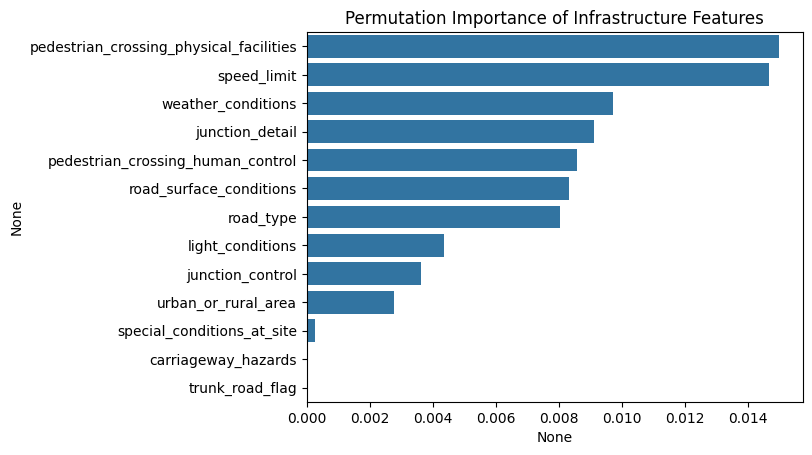

In [5]:
perm_importances = pd.Series(result.importances_mean, index=infra_cols).sort_values(ascending=False)
sns.barplot(x=perm_importances, y=perm_importances.index)
plt.title("Permutation Importance of Infrastructure Features")

In [ ]:
# %pip install shap
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values, X, plot_type="bar")
shap.summary_plot(shap_values, X)  # Detailed version

In [131]:
# Chi squared test of independence
from scipy.stats import chi2_contingency

for col in infra_cols:
    contingency = pd.crosstab(df_with_risk[col], df_with_risk['refined_risk_level'])
    chi2, p, _, _ = chi2_contingency(contingency)
    print(f"{col}: p = {p:.4f}")


road_type: p = 0.0000
speed_limit: p = 0.0000
junction_detail: p = 0.0000
junction_control: p = 0.0000
pedestrian_crossing_human_control: p = 0.0019
pedestrian_crossing_physical_facilities: p = 0.0000
light_conditions: p = 0.0000
weather_conditions: p = 0.0000
road_surface_conditions: p = 0.0000
special_conditions_at_site: p = 0.0000
carriageway_hazards: p = 0.0003
urban_or_rural_area: p = 0.0000
trunk_road_flag: p = 0.3189


In [132]:
for col in infra_cols:
    display(pd.crosstab(df_with_risk[col], df_with_risk['refined_risk_level'], normalize='index'))


refined_risk_level,Critical Risk,High Risk,Moderate Risk,Normal Risk
road_type,,,,
1,0.014925,0.009950,0.029851,0.945274
2,0.000000,0.000000,0.000000,1.000000
3,0.021750,0.000509,0.000000,0.977741
6,0.056056,0.006340,0.016826,0.920778
7,0.165217,0.000000,0.000000,0.834783
9,0.068966,0.000000,0.000000,0.931034


refined_risk_level,Critical Risk,High Risk,Moderate Risk,Normal Risk
speed_limit,,,,
20.0,0.055092,0.018364,0.098497,0.828047
30.0,0.051705,0.009051,0.011816,0.927428
40.0,0.047251,0.000386,0.010622,0.941741
50.0,0.001656,0.000000,0.000000,0.998344
60.0,0.009674,0.019347,0.000000,0.970979
70.0,0.000000,0.000000,0.000000,1.000000


refined_risk_level,Critical Risk,High Risk,Moderate Risk,Normal Risk
junction_detail,,,,
0,0.034839,0.001618,0.011151,0.952392
1,0.035836,0.006826,0.020478,0.936860
2,0.000000,0.000000,0.000000,1.000000
3,0.050730,0.011737,0.004956,0.932577
5,0.312500,0.000000,0.000000,0.687500
6,0.160487,0.003320,0.051467,0.784726
7,0.021429,0.000000,0.014286,0.964286
8,0.100000,0.033333,0.016667,0.850000
9,0.022828,0.006975,0.016487,0.953710


refined_risk_level,Critical Risk,High Risk,Moderate Risk,Normal Risk
junction_control,,,,
-1,0.034837,0.001618,0.011150,0.952395
1,0.111111,0.000000,0.000000,0.888889
2,0.113458,0.004420,0.044695,0.837426
3,0.002674,0.000000,0.034759,0.962567
4,0.056932,0.010649,0.006963,0.925456


refined_risk_level,Critical Risk,High Risk,Moderate Risk,Normal Risk
pedestrian_crossing_human_control,,,,
0,0.047230,0.004882,0.012604,0.935284
1,0.074303,0.000000,0.003096,0.922601
2,0.016667,0.000000,0.000000,0.983333


...

refined_risk_level,Critical Risk,High Risk,Moderate Risk,Normal Risk
road_surface_conditions,,,,
-1,1.000000,0.000000,0.000000,0.000000
1,0.048273,0.004010,0.011773,0.935945
2,0.045195,0.006299,0.013599,0.934907
4,0.000000,0.000000,0.000000,1.000000


refined_risk_level,Critical Risk,High Risk,Moderate Risk,Normal Risk
special_conditions_at_site,,,,
0,0.045968,0.00487,0.012606,0.936557
2,0.066667,0.00000,0.000000,0.933333
4,0.140845,0.00000,0.000000,0.859155
5,0.000000,0.00000,0.000000,1.000000


refined_risk_level,Critical Risk,High Risk,Moderate Risk,Normal Risk
carriageway_hazards,,,,
0,0.048118,0.004909,0.012708,0.934264
2,0.013477,0.000000,0.000000,0.986523
3,0.000000,0.000000,0.000000,1.000000
6,0.000000,0.000000,0.000000,1.000000
7,0.083333,0.000000,0.000000,0.916667


refined_risk_level,Critical Risk,High Risk,Moderate Risk,Normal Risk
urban_or_rural_area,,,,
1,0.052149,0.004526,0.012657,0.930668
2,0.020062,0.006173,0.010802,0.962963


refined_risk_level,Critical Risk,High Risk,Moderate Risk,Normal Risk
trunk_road_flag,,,,
1,0.000000,0.000000,0.000000,1.000000
2,0.047297,0.004787,0.012393,0.935522


In [139]:
# %pip uninstall umap
%pip install umap-learn
import umap
reducer = umap.UMAP(random_state=42)
X_umap = reducer.fit_transform(X)

df_pca['UMAP1'], df_pca['UMAP2'] = X_umap[:, 0], X_umap[:, 1]

sns.scatterplot(data=df_pca, x='UMAP1', y='UMAP2', hue='final_risk_level')
plt.title('UMAP of Infrastructure Features by Risk Level')


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


AttributeError: module 'umap' has no attribute 'UMAP'

### 3. Percentile Rankings
We add columns for percentile ranks for each of the previously defined metrics.

In [ ]:
normalised_cols = [f"{col}_per_km" for col in metric_cols]
crm_table = crm.add_percentile_metrics(crm_table, normalised_cols)
display(crm_table)

,route_id,school_name,borough,length_km,collision_count,casualty_count,avg_casualty_severity,serious_fatal_casualty_count,collision_count_per_km,casualty_count_per_km,avg_casualty_severity_per_km,serious_fatal_casualty_count_per_km,collision_count_per_km_percentile,casualty_count_per_km_percentile,avg_casualty_severity_per_km_percentile,serious_fatal_casualty_count_per_km_percentile
0,de_warenne_academy_15,De Warenne Academy,Doncaster,6.622,69,98,2.612245,28,10.419813,14.799154,0.394480,4.228330,0.810974,0.801703,0.050710,0.979376
1,don_valley_academy_7,Don Valley Academy,Doncaster,6.626,22,32,2.718750,8,3.320254,4.829460,0.410315,1.207365,0.366320,0.342857,0.061306,0.651088
2,ridgewood_school_6,Ridgewood School,Doncaster,5.890,10,15,2.600000,5,1.697793,2.546689,0.441426,0.848896,0.196594,0.189593,0.086850,0.532450
3,sir_thomas_wharton_academy_16,Sir Thomas Wharton Academy,Doncaster,5.807,84,117,2.837607,17,14.465300,20.148097,0.488653,2.927501,0.911637,0.904068,0.166887,0.927342
4,stone_hill_school_6,Stone Hill School,Doncaster,5.683,10,14,2.714286,3,1.759634,2.463488,0.477615,0.527890,0.202649,0.183160,0.142100,0.391864
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5280,the_robert_ogden_school_21,The Robert Ogden School,Barnsley,6.141,1,1,3.000000,0,0.162840,0.162840,0.488520,0.000000,0.007569,0.006623,0.166131,0.092621
5281,the_robert_ogden_school_22,The Robert Ogden School,Barnsley,6.676,1,1,3.000000,0,0.149790,0.149790,0.449371,0.000000,0.006055,0.005487,0.097256,0.092621
5282,sacred_heart_rc_primary_school_6,Sacred Heart Rc Primary School,Barnsley,2.288,1,2,3.000000,0,0.437063,0.874126,1.311189,0.000000,0.049763,0.067550,0.837086,0.092621
5283,meersbrook_bank_primary_1,Meersbrook Bank Primary,Sheffield,0.742,1,4,3.000000,0,1.347709,5.390836,4.043127,0.000000,0.157900,0.379092,0.987039,0.092621


In [136]:
feature_summary = pd.DataFrame({
    'Feature': perm_importances.index,
    'Importance': perm_importances.values
})
feature_summary.to_csv("feature_ranking.csv", index=False)
feature_summary


,Feature,Importance
0,pedestrian_crossing_physical_facilities,0.015002
1,speed_limit,0.014673
2,weather_conditions,0.009714
3,junction_detail,0.009118
4,pedestrian_crossing_human_control,0.008579
5,road_surface_conditions,0.008314
6,road_type,0.008023
7,light_conditions,0.004369
8,junction_control,0.003623
9,urban_or_rural_area,0.002769
